In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
df = pd.read_csv('../dataset/Walmart.csv')

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Convert to epoch time in seconds
df['Date'] = df['Date'].astype(int) // 10**9 

# Set Date as index
df.set_index('Date', inplace=True)

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'Holiday_Flag': 'max',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).reset_index()

df.head()

# Graph
#result = seasonal_decompose(df['FEDFUNDS'], model ='multiplicative')
#result.plot()

# data["detrended"] = sm.OLS(data["FEDFUNDS"], sm.add_constant(range(len(data)))).fit().resid
# data["differenced"] = data["FEDFUNDS"].diff()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1265328000,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,1265932800,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,1266537600,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,1267142400,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,1267747200,46871470.30,0,42.917333,2.731200,167.947628,8.619311


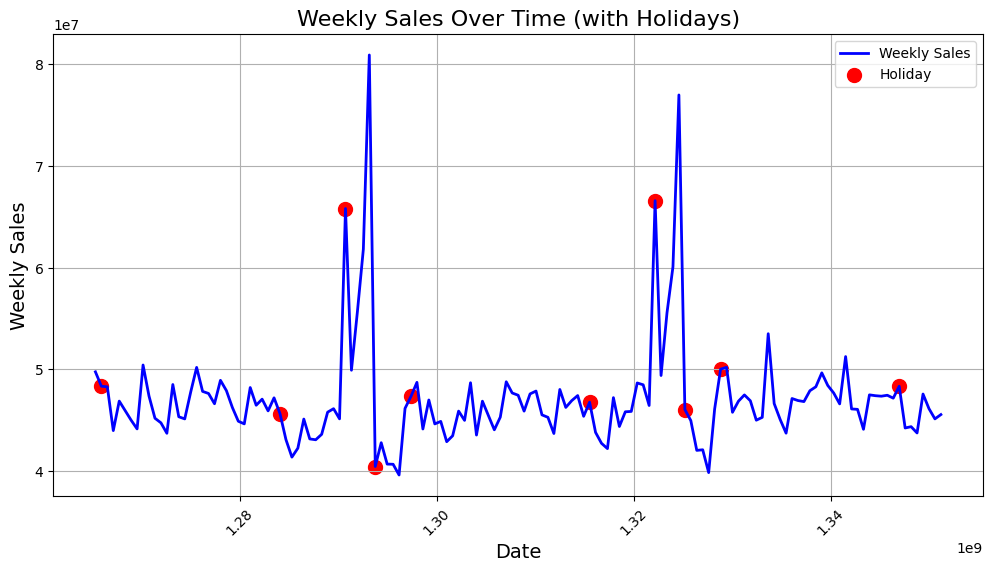

In [15]:
# Plot Weekly Sales over Time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Weekly_Sales'], color='blue', linewidth=2, label='Weekly Sales')

# Highlight Holidays
holiday_dates = df[df['Holiday_Flag'] == 1]  # Filter rows where Holiday_Flag is 1
plt.scatter(holiday_dates['Date'], holiday_dates['Weekly_Sales'], color='red', marker='o', s=100, label='Holiday')

# Add titles and labels
plt.title('Weekly Sales Over Time (with Holidays)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales', fontsize=14)
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show the plot
plt.show()

In [16]:
# ADF Test
result_test = adfuller(df['Weekly_Sales'])

print(f"ADF Statistic: {result_test[0]}")
print(f"P-value: {result_test[1]}")
print(f"Critical Values: {result_test[4]}")

if result_test[1] < 0.05:
    print("Reject H0: Data is stationary")
else:
    print("Fail to reject H0: Data is non-stationary")

ADF Statistic: -5.908297957186335
P-value: 2.675979158986003e-07
Critical Values: {'1%': np.float64(-3.47864788917503), '5%': np.float64(-2.882721765644168), '10%': np.float64(-2.578065326612056)}
Reject H0: Data is stationary


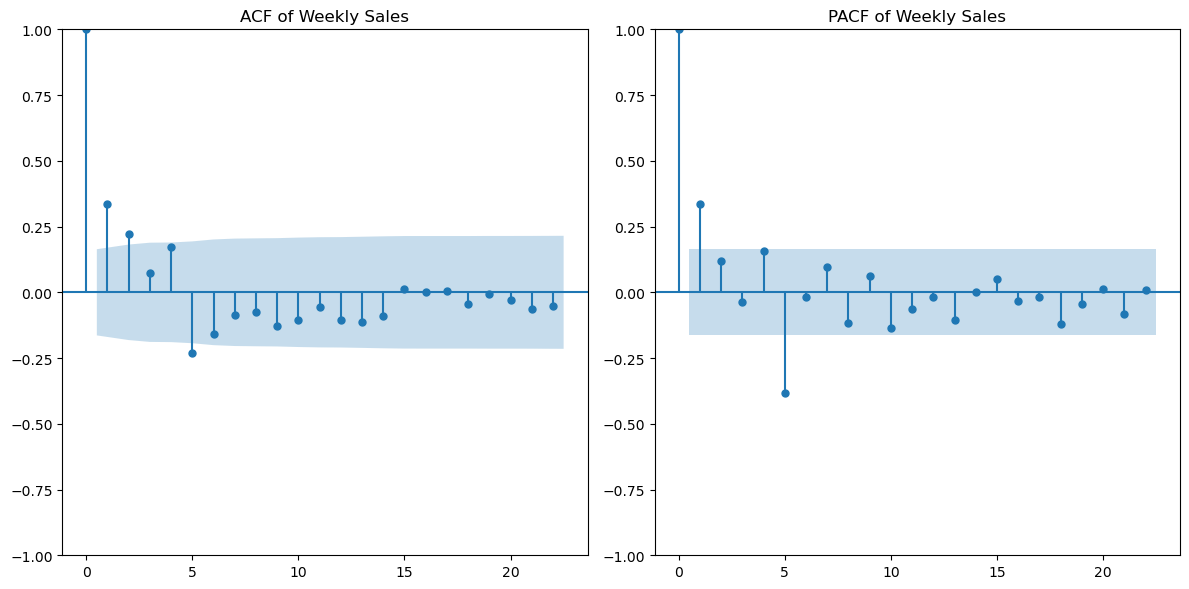

/opt/anaconda3/envs/Demand-Forecast/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Mean Absolute Error (MAE): 2080014.994579263
Mean Squared Error (MSE): 13184544876494.0
Root Mean Squared Error (RMSE): 3631052.860603106
R-squared (R²): 0.5520353915167545


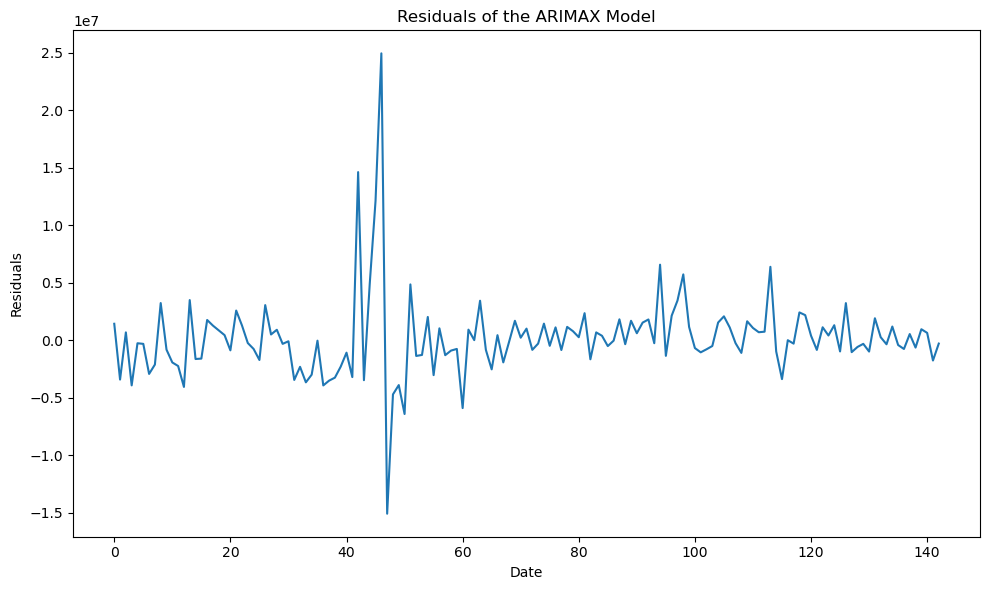

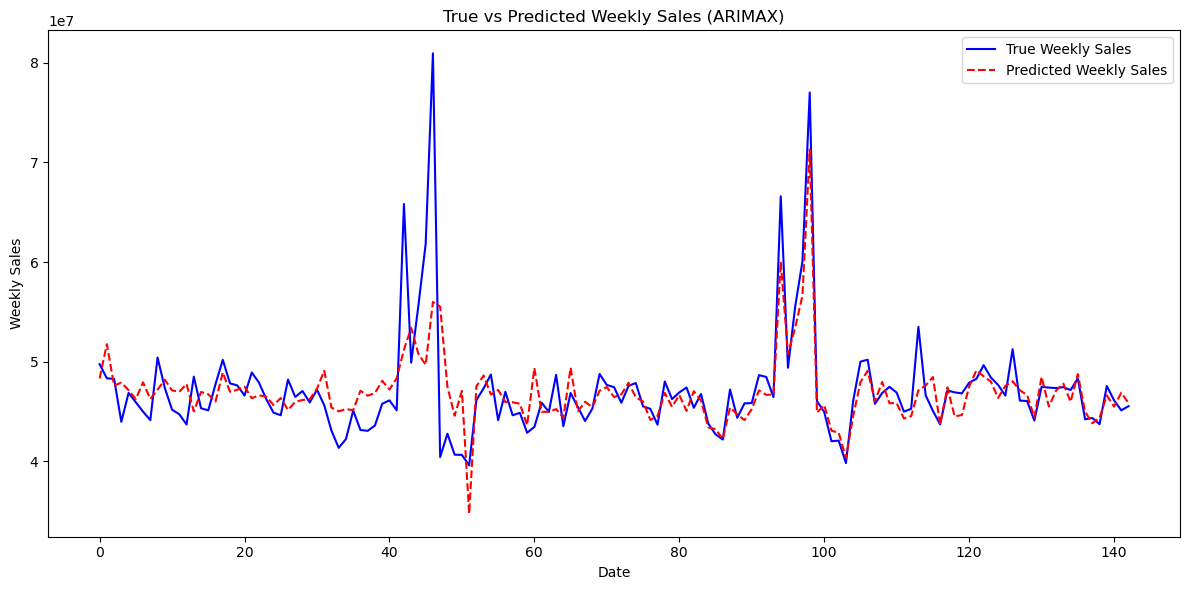

In [13]:
# Plot ACF and PACF for Weekly_Sales to determine p, d, q
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_acf(df['Weekly_Sales'], ax=axes[0], title="ACF of Weekly Sales")
plot_pacf(df['Weekly_Sales'], ax=axes[1], title="PACF of Weekly Sales")
plt.tight_layout()
plt.show()

# Define target variable and exogenous variables
y = df['Weekly_Sales']
X = df[['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']]

# Function to fit the ARIMAX model
def fit_arimax(p, d, q):
    try:
        model = SARIMAX(y, exog=X, order=(p, d, q), seasonal_order=(p, d, q, 52))
        fitted_model = model.fit()
        return (p, d, q, fitted_model.aic, fitted_model)
    except Exception as e:
        print(e)
        return None

best_params = fit_arimax(1, 0, 5)

# Extract the best model
best_model = best_params[4]

# If a valid model was found, generate predictions
if best_model is not None:
    # Make predictions with the best ARIMAX model
    y_true = y
    y_pred = best_model.predict(start=0, end=len(y)-1, exog=X)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # Display the metrics
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared (R²): {r2}")

    # Optional: Plot residuals to check if they resemble white noise
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    plt.plot(residuals)
    plt.title("Residuals of the ARIMAX Model")
    plt.xlabel("Date")
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()

    # Plot predicted vs. true Weekly Sales
    plt.figure(figsize=(12, 6))
    plt.plot(y, label="True Weekly Sales", color='blue')
    plt.plot(y_pred, label="Predicted Weekly Sales", color='red', linestyle='--')
    plt.legend()
    plt.title("True vs Predicted Weekly Sales (ARIMAX)")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.tight_layout()
    plt.show()
else:
    print("No valid model was found!")